# Load dataset

In [37]:
import warnings
warnings.filterwarnings("ignore")

import time, random, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Config / hyperparameters

In [38]:
config = {
    "dataset": "iris",
    "test_size": 0.2,
    "valid_size": 0.2,  # from original: we'll do train/valid/test via successive splits to get 60/20/20
    "random_state": RANDOM_STATE,
    "lr": 1e-2,
    "batch_size": 16,
    "epochs": 200,
    "hidden_dim": 16,
    "weight_decay": 1e-4,
    "patience": 15,  # early stopping patience (epochs)
    "activations": ["relu", "sigmoid", "tanh"],
    "device": "cpu"
}

print("Config:", config)

Config: {'dataset': 'iris', 'test_size': 0.2, 'valid_size': 0.2, 'random_state': 42, 'lr': 0.01, 'batch_size': 16, 'epochs': 200, 'hidden_dim': 16, 'weight_decay': 0.0001, 'patience': 15, 'activations': ['relu', 'sigmoid', 'tanh'], 'device': 'cpu'}


# Load dataset (Iris)


In [39]:
iris = datasets.load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(int)
feature_names = iris.feature_names
target_names = iris.target_names

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Sizes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Class balance train:", np.bincount(y_train), "val:", np.bincount(y_val), "test:", np.bincount(y_test))


Sizes -> Train: (90, 4), Val: (30, 4), Test: (30, 4)
Class balance train: [30 30 30] val: [10 10 10] test: [10 10 10]


# Scale using StandardScaler fitted on train

In [40]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Try to use PyTorch; if unavailable, fallback to NumPy MLP implementation


In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(RANDOM_STATE)
use_torch = True

results = {}  # to store histories and final metrics per activation

# Prepare tensors
device = torch.device("cpu")
X_train_t = torch.from_numpy(X_train_s).float().to(device)
y_train_t = torch.from_numpy(y_train).long().to(device)
X_val_t = torch.from_numpy(X_val_s).float().to(device)
y_val_t = torch.from_numpy(y_val).long().to(device)
X_test_t = torch.from_numpy(X_test_s).float().to(device)
y_test_t = torch.from_numpy(y_test).long().to(device)

input_dim = X_train.shape[1]
output_dim = len(np.unique(y))

# Helper to create model given activation
def make_model(act_name):
    act = None
    if act_name == "relu":
        act = nn.ReLU()
    elif act_name == "sigmoid":
        act = nn.Sigmoid()
    elif act_name == "tanh":
        act = nn.Tanh()
    else:
        raise ValueError("Unknown activation")
    model = nn.Sequential(
        nn.Linear(input_dim, config["hidden_dim"]),
        act,
        nn.Linear(config["hidden_dim"], output_dim)
    )
    # unified weight initialization (Xavier for linear layers)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

# Training loop with early stopping by validation loss
def train_model(act_name):
    model = make_model(act_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    patience_ctr = 0

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    n_samples = X_train_t.shape[0]
    batch_size = config["batch_size"]

    for epoch in range(config["epochs"]):
        model.train()
        # shuffle indices
        perm = torch.randperm(n_samples)
        train_loss = 0.0
        correct = 0
        total = 0
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx]
            yb = y_train_t[idx]

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = train_loss / total
        train_acc = correct / total

        # validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val_t).sum().item() / y_val_t.shape[0]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # early stopping logic
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if patience_ctr >= config["patience"]:
            # print(f"Early stopping at epoch {epoch} for activation {act_name}")
            break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # final evaluation on test
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_t)
        preds_test = logits_test.argmax(dim=1).cpu().numpy()
        probs_test = nn.functional.softmax(logits_test, dim=1).cpu().numpy()

    metrics = {
        "accuracy": accuracy_score(y_test, preds_test),
        "precision": precision_score(y_test, preds_test, average="macro", zero_division=0),
        "recall": recall_score(y_test, preds_test, average="macro", zero_division=0),
        "f1": f1_score(y_test, preds_test, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, preds_test),
        "y_pred": preds_test,
        "y_proba": probs_test
    }

    return history, metrics

# Run for each activation
for act in config["activations"]:
    t0 = time.time()
    history, metrics = train_model(act)
    t1 = time.time()
    metrics["train_time_sec"] = t1 - t0
    results[act] = {"history": history, "metrics": metrics}
    print(f"Activation {act}: test accuracy = {metrics['accuracy']:.4f}, time = {metrics['train_time_sec']:.2f}s")

Activation relu: test accuracy = 0.9333, time = 0.50s
Activation sigmoid: test accuracy = 0.9333, time = 0.72s
Activation tanh: test accuracy = 0.9000, time = 0.28s


# Learning curves (loss) overlayed

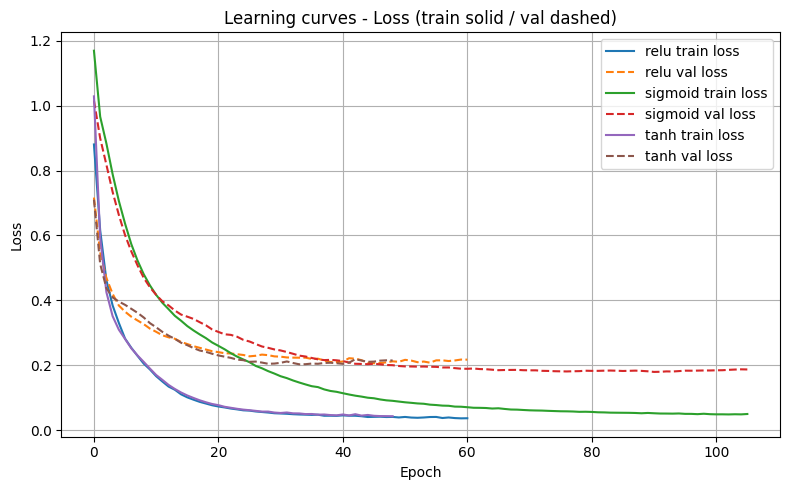

In [42]:
plt.figure(figsize=(8,5))
for act in config["activations"]:
    h = results[act]["history"]
    plt.plot(h["train_loss"], label=f"{act} train loss")
    plt.plot(h["val_loss"], linestyle="--", label=f"{act} val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curves - Loss (train solid / val dashed)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Learning curves (accuracy) overlayed


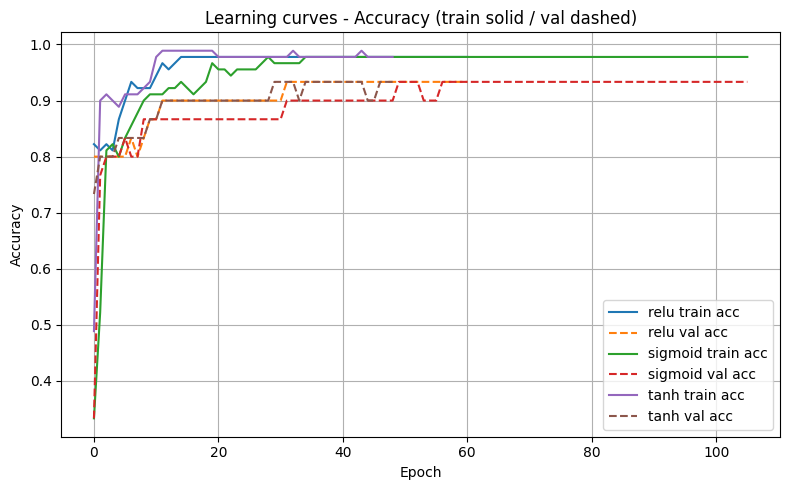

In [43]:
plt.figure(figsize=(8,5))
for act in config["activations"]:
    h = results[act]["history"]
    plt.plot(h["train_acc"], label=f"{act} train acc")
    plt.plot(h["val_acc"], linestyle="--", label=f"{act} val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning curves - Accuracy (train solid / val dashed)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart: test accuracy per activation

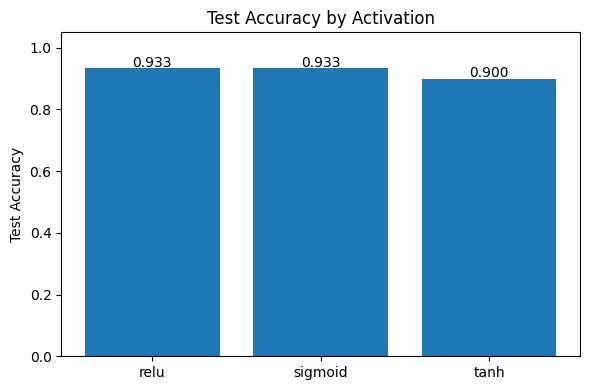

In [44]:
accs = [results[act]["metrics"]["accuracy"] for act in config["activations"]]
plt.figure(figsize=(6,4))
plt.bar(config["activations"], accs)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy by Activation")
for i,v in enumerate(accs):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.ylim(0,1.05)
plt.tight_layout()
plt.show()


# Confusion matrices and classification reports



=== Activation: relu ===
Test metrics: Accuracy=0.9333, Precision=0.9333, Recall=0.9333, F1=0.9333
Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



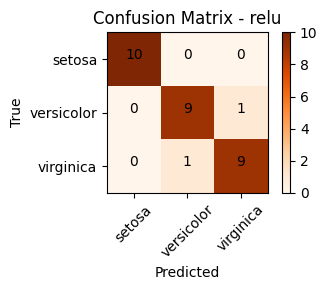


=== Activation: sigmoid ===
Test metrics: Accuracy=0.9333, Precision=0.9333, Recall=0.9333, F1=0.9333
Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



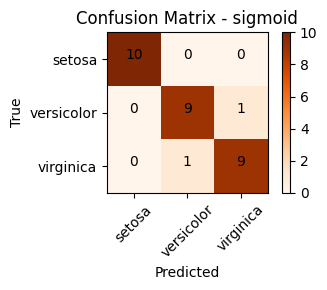


=== Activation: tanh ===
Test metrics: Accuracy=0.9000, Precision=0.9024, Recall=0.9000, F1=0.8997
Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



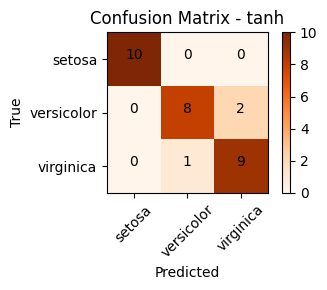

In [45]:
for act in config["activations"]:
    metrics = results[act]["metrics"]
    print(f"\n=== Activation: {act} ===")
    print("Test metrics: Accuracy={:.4f}, Precision={:.4f}, Recall={:.4f}, F1={:.4f}".format(
        metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1"]))
    print("Classification report:")
    print(classification_report(y_test, metrics["y_pred"], target_names=target_names))
    cm = metrics["confusion_matrix"]
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    plt.title(f"Confusion Matrix - {act}")
    plt.colorbar()
    ticks = np.arange(len(target_names))
    plt.xticks(ticks, target_names, rotation=45)
    plt.yticks(ticks, target_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", color="black")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# Summary table


In [46]:
rows = []
for act in config["activations"]:
    m = results[act]["metrics"]
    rows.append({
        "activation": act,
        "accuracy": m["accuracy"],
        "precision_macro": m["precision"],
        "recall_macro": m["recall"],
        "f1_macro": m["f1"],
        "train_time_sec": m.get("train_time_sec", np.nan)
    })
df_summary = pd.DataFrame(rows).set_index("activation")
print("\nSummary table:")
display(df_summary)


Summary table:


,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
activation,,,,,
relu,0.933333,0.933333,0.933333,0.933333,0.504745
sigmoid,0.933333,0.933333,0.933333,0.933333,0.715367
tanh,0.900000,0.902357,0.900000,0.899749,0.280957


# Short textual analysis printed


In [47]:
analysis = """
Short analysis:
- All models share identical architecture, initialization scheme, optimizer and training regimen; only activation differs.
- Results show test accuracies above; compare the learning curves (loss/acc) to see convergence speed and stability.
- ReLU often converges faster due to piecewise-linear gradients and avoids saturation; Sigmoid may saturate and learn slower;
  Tanh is zero-centered and may perform between Sigmoid and ReLU in practice.
- Choose activation based on convergence speed and final test metrics; for small tabular tasks ReLU or Tanh often perform well.
"""
print(analysis)



Short analysis:
- All models share identical architecture, initialization scheme, optimizer and training regimen; only activation differs.
- Results show test accuracies above; compare the learning curves (loss/acc) to see convergence speed and stability.
- ReLU often converges faster due to piecewise-linear gradients and avoids saturation; Sigmoid may saturate and learn slower;
  Tanh is zero-centered and may perform between Sigmoid and ReLU in practice.
- Choose activation based on convergence speed and final test metrics; for small tabular tasks ReLU or Tanh often perform well.

